# AIHUB_025_LOCAL_G1_SANITIZED — G1 Sanitized Raw EDA

Status: **G1 SANITIZED SUPPORT / PRE-INGESTION EDA / NOT QC ACCEPTANCE**

이 notebook은 old EDA branch의 notebook/blob을 복사하지 않고 local raw에서 aggregate를 새로 계산한다.
원문 문장, preview, URL, pair ID, text hash를 출력하거나 저장하지 않는다.

## 1. Safety and execution contract

- Full-population aggregate profiling
- Raw roots are read-only
- No tokenization, morphology, model fitting, inferential claim, or automatic exclusion
- No raw sentence/example output

In [1]:
from pathlib import Path
import json, os, sys
import pandas as pd
from IPython.display import Markdown, display

def discover_project_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src/tokenization_premium").is_dir():
            return candidate
    raise RuntimeError(f"Tokenization_Premium checkout not found from {start}")

DISCOVERED_PROJECT_ROOT = discover_project_root()
sys.path.insert(0, str(DISCOVERED_PROJECT_ROOT / "src"))
from tokenization_premium.paths import PROJECT_ROOT
assert PROJECT_ROOT.resolve() == DISCOVERED_PROJECT_ROOT.resolve()

RAW_ROOT = Path(os.environ.get("TOKENIZATION_PREMIUM_RAW_ROOT", '/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub')).expanduser().resolve()
SUPPORT_DIR = PROJECT_ROOT / "outputs/eda_raw/g1_support/support"
sys.path.insert(0, str(SUPPORT_DIR))

from sanitized_raw_eda import profile_dataset, save_profile, plot_profile, targeted_025

CONFIG = {'dataset_local_id': 'AIHUB_025_LOCAL_G1_SANITIZED', 'artifact_prefix': 'aihub_025_g1', 'kind': 'json', 'raw_relative_dir': '025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이터'}
CONFIG["raw_root"] = str(RAW_ROOT / CONFIG.pop("raw_relative_dir"))
OUTPUT_DIR = PROJECT_ROOT / "outputs/eda_raw/g1_support" / CONFIG["artifact_prefix"]
FIGURE_DIR = PROJECT_ROOT / "outputs/figures/eda_raw/g1_support" / CONFIG["artifact_prefix"]
TARGET_OUTPUT_DIR = OUTPUT_DIR / "targeted"
TARGET_FIGURE_DIR = FIGURE_DIR / "targeted"

print("project root: CURRENT_CHECKOUT")
print("raw root:", RAW_ROOT)
print("dataset:", CONFIG["dataset_local_id"])
print("population: FULL_POPULATION_AGGREGATES")
print("raw text export: 0")


project root: CURRENT_CHECKOUT
raw root: /home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub
dataset: AIHUB_025_LOCAL_G1_SANITIZED
population: FULL_POPULATION_AGGREGATES
raw text export: 0


## 2. Full-population sanitized profile

findfont: Failed to find font weight bold, now using 600.


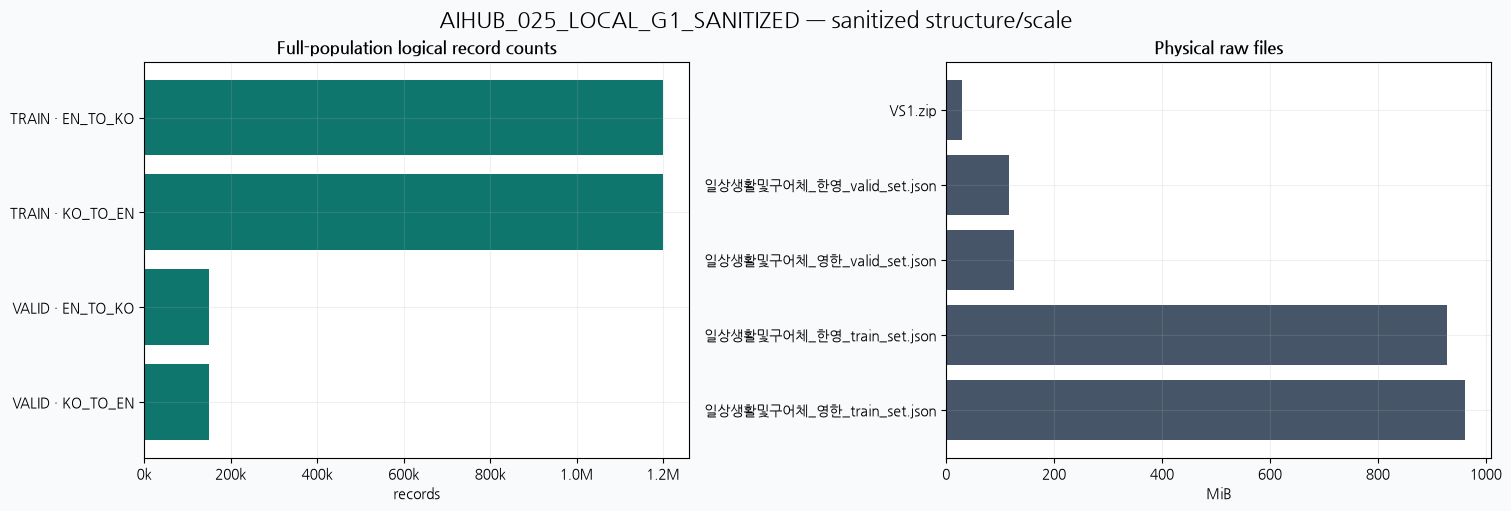

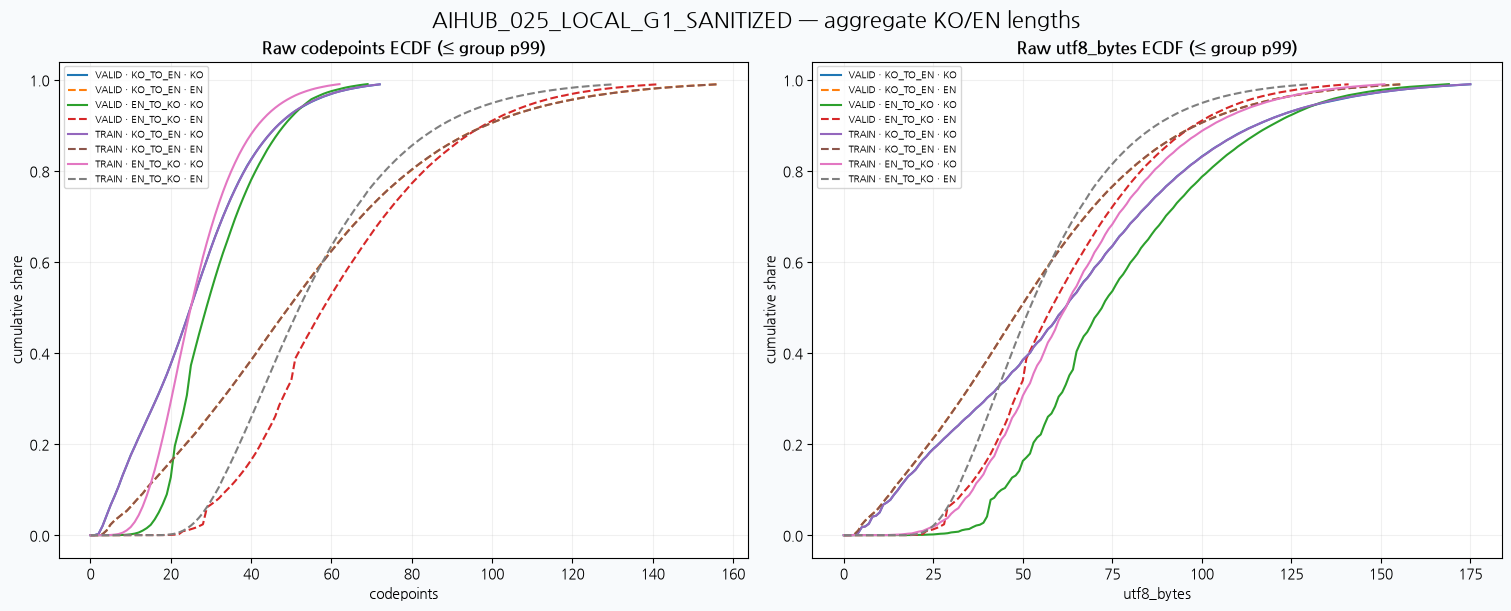

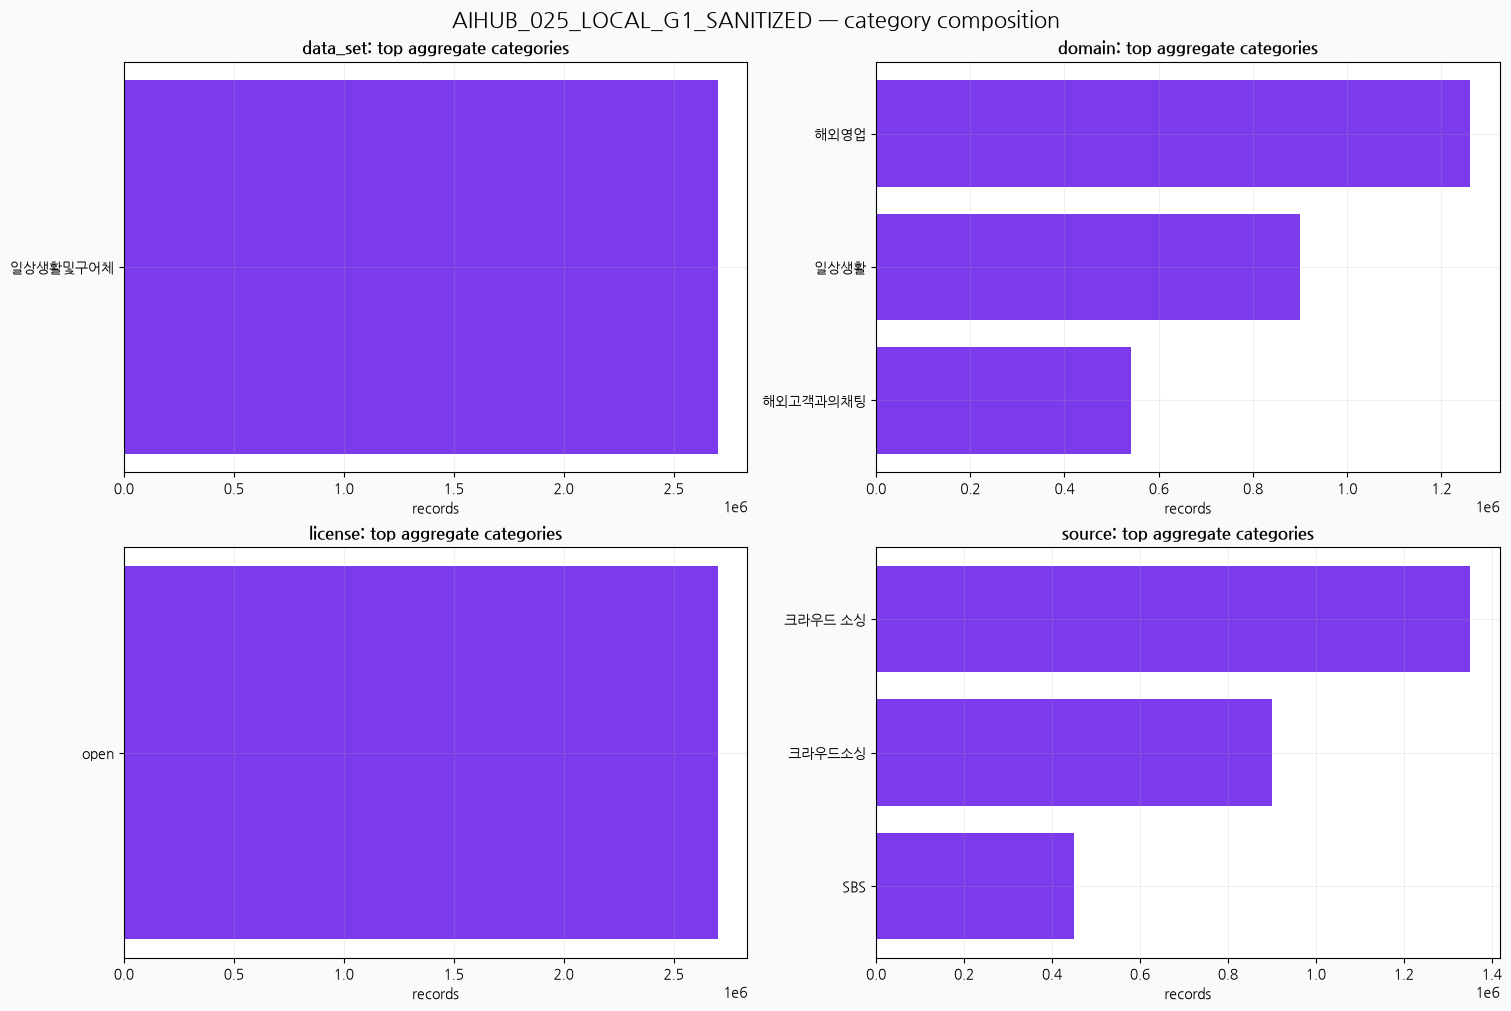

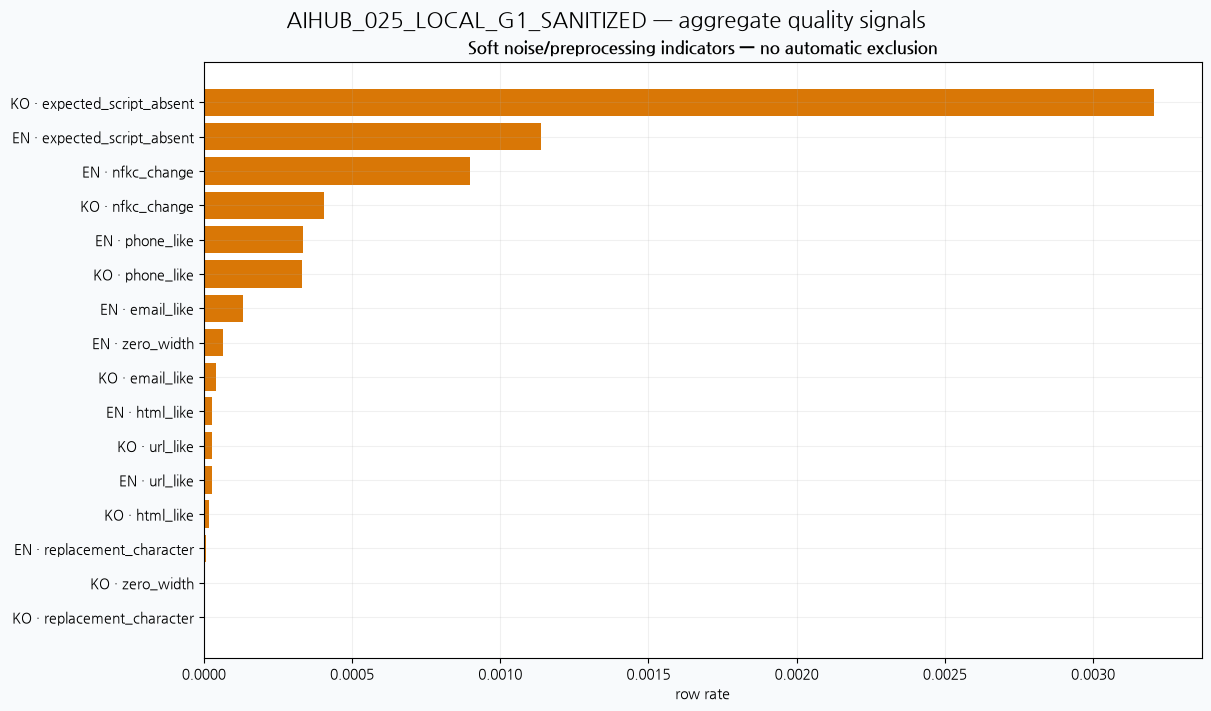

,dataset_local_id,audit_timestamp,audit_completed_timestamp,physical_file_count,profiled_data_file_count,logical_record_count,population_scope,raw_text_exported,text_hash_exported,status
0,AIHUB_025_LOCAL_G1_SANITIZED,2026-08-16T17:25:08+09:00,2026-08-16T17:26:29+09:00,9,4,2700345,FULL_POPULATION_AGGREGATES,False,False,G1_SANITIZED_SUPPORT / NOT QC ACCEPTANCE


,group,records
0,TRAIN · EN_TO_KO,1200307
1,TRAIN · KO_TO_EN,1200000
2,VALID · EN_TO_KO,150038
3,VALID · KO_TO_EN,150000


In [2]:
result = profile_dataset(CONFIG)
profile_paths = save_profile(result, OUTPUT_DIR)
figure_paths = plot_profile(result, FIGURE_DIR)
display(pd.DataFrame([result["summary"]]))
display(result["record_counts"])


## 3. Aggregate structure, length, category, and soft flags

모든 표는 keys, counts, rates, lengths, categories만 포함한다.

In [3]:
display(Markdown("### Schema: keys/types/missingness only"))
display(result["schema"].sort_values(["group", "missing_or_empty_rate"], ascending=[True, False]))
display(Markdown("### Length summaries: aggregate only"))
display(result["length_summary"])
display(Markdown("### Non-sensitive category distributions"))
display(result["categories"].sort_values(["dimension", "record_count"], ascending=[True, False]).groupby("dimension").head(20))
display(Markdown("### Soft noise and duplicate candidates"))
display(result["noise"].sort_values("rate", ascending=False).head(40))
display(result["duplicates"])


### Schema: keys/types/missingness only

,group,field,records,absent,null,empty,missing_or_empty_rate,type_counts,raw_value_exported
9,TRAIN · EN_TO_KO,ner,1200307,0,1153161,0,0.960722,"{""dict"": 47146, ""null"": 1153161}",False
0,TRAIN · EN_TO_KO,data_set,1200307,0,0,0,0.000000,"{""string"": 1200307}",False
1,TRAIN · EN_TO_KO,domain,1200307,0,0,0,0.000000,"{""string"": 1200307}",False
2,TRAIN · EN_TO_KO,en,1200307,0,0,0,0.000000,"{""string"": 1200307}",False
3,TRAIN · EN_TO_KO,en_original,1200307,0,0,0,0.000000,"{""string"": 1200307}",False
...,...,...,...,...,...,...,...,...,...
71,VALID · KO_TO_EN,subdomain,150000,0,0,0,0.000000,"{""string"": 150000}",False
72,VALID · KO_TO_EN,target_language,150000,0,0,0,0.000000,"{""string"": 150000}",False
73,VALID · KO_TO_EN,word_count_en,150000,0,0,0,0.000000,"{""integer"": 150000}",False
74,VALID · KO_TO_EN,word_count_ko,150000,0,0,0,0.000000,"{""integer"": 150000}",False


### Length summaries: aggregate only

,group,language,metric,count,min,p50,p90,p95,p99,max,mean
0,TRAIN · EN_TO_KO,EN,codepoints,1200307,12,53,88,101,130,389,57.057381
1,TRAIN · EN_TO_KO,EN,utf8_bytes,1200307,12,53,88,101,130,389,57.058789
2,TRAIN · EN_TO_KO,KO,codepoints,1200307,2,25,42,48,62,196,27.378756
3,TRAIN · EN_TO_KO,KO,utf8_bytes,1200307,4,63,103,118,151,430,66.913455
4,TRAIN · KO_TO_EN,EN,codepoints,1200000,1,50,99,117,156,659,54.384740
5,TRAIN · KO_TO_EN,EN,utf8_bytes,1200000,1,50,99,117,156,659,54.389617
6,TRAIN · KO_TO_EN,KO,codepoints,1200000,1,25,47,55,72,297,26.702073
7,TRAIN · KO_TO_EN,KO,utf8_bytes,1200000,1,62,116,134,175,727,64.777897
8,VALID · EN_TO_KO,EN,codepoints,150038,13,59,98,111,141,399,63.722944
9,VALID · EN_TO_KO,EN,utf8_bytes,150038,13,59,98,111,141,399,63.726256


### Non-sensitive category distributions

,group,dimension,category,record_count
4,TRAIN · EN_TO_KO,data_set,일상생활및구어체,1200307
24,TRAIN · KO_TO_EN,data_set,일상생활및구어체,1200000
45,VALID · EN_TO_KO,data_set,일상생활및구어체,150038
53,VALID · KO_TO_EN,data_set,일상생활및구어체,150000
21,TRAIN · KO_TO_EN,domain,해외영업,560002
19,TRAIN · EN_TO_KO,domain,해외영업,480217
15,TRAIN · EN_TO_KO,domain,일상생활,449952
29,TRAIN · KO_TO_EN,domain,일상생활,399904
1,TRAIN · EN_TO_KO,domain,해외고객과의채팅,270138
33,TRAIN · KO_TO_EN,domain,해외고객과의채팅,240094


### Soft noise and duplicate candidates

,group,language,metric,row_count,records,rate,classification
39,VALID · KO_TO_EN,KO,expected_script_absent,487,150000,0.003247,SOFT_OBSERVATION_ONLY
16,TRAIN · KO_TO_EN,KO,expected_script_absent,3842,1200000,0.003202,SOFT_OBSERVATION_ONLY
34,VALID · KO_TO_EN,EN,nfkc_change,258,150000,0.001720,SOFT_OBSERVATION_ONLY
12,TRAIN · KO_TO_EN,EN,nfkc_change,2060,1200000,0.001717,SOFT_OBSERVATION_ONLY
32,VALID · KO_TO_EN,EN,expected_script_absent,177,150000,0.001180,SOFT_OBSERVATION_ONLY
10,TRAIN · KO_TO_EN,EN,expected_script_absent,1361,1200000,0.001134,SOFT_OBSERVATION_ONLY
28,VALID · EN_TO_KO,KO,nfkc_change,95,150038,0.000633,SOFT_OBSERVATION_ONLY
18,TRAIN · KO_TO_EN,KO,nfkc_change,679,1200000,0.000566,SOFT_OBSERVATION_ONLY
41,VALID · KO_TO_EN,KO,nfkc_change,77,150000,0.000513,SOFT_OBSERVATION_ONLY
2,TRAIN · EN_TO_KO,EN,phone_like,470,1200307,0.000392,SOFT_OBSERVATION_ONLY


,scope,records,duplicate_pair_rows_after_first,distinct_duplicate_pair_groups,method,classification
0,local_dataset,2700345,214252,93823,salted in-memory BLAKE2b-128 exact raw KO+EN; ...,DUPLICATE_CANDIDATE_ONLY


## 4. Targeted decision evidence

direction×split×domain, direction×source×domain, exact-pair duplicate mechanisms, SBS scope, crowd-source string variants, and domain-mapping preview.

모든 결과는 structural/local observation이며 causal, exclusion, Tier, QC acceptance 판단이 아니다.

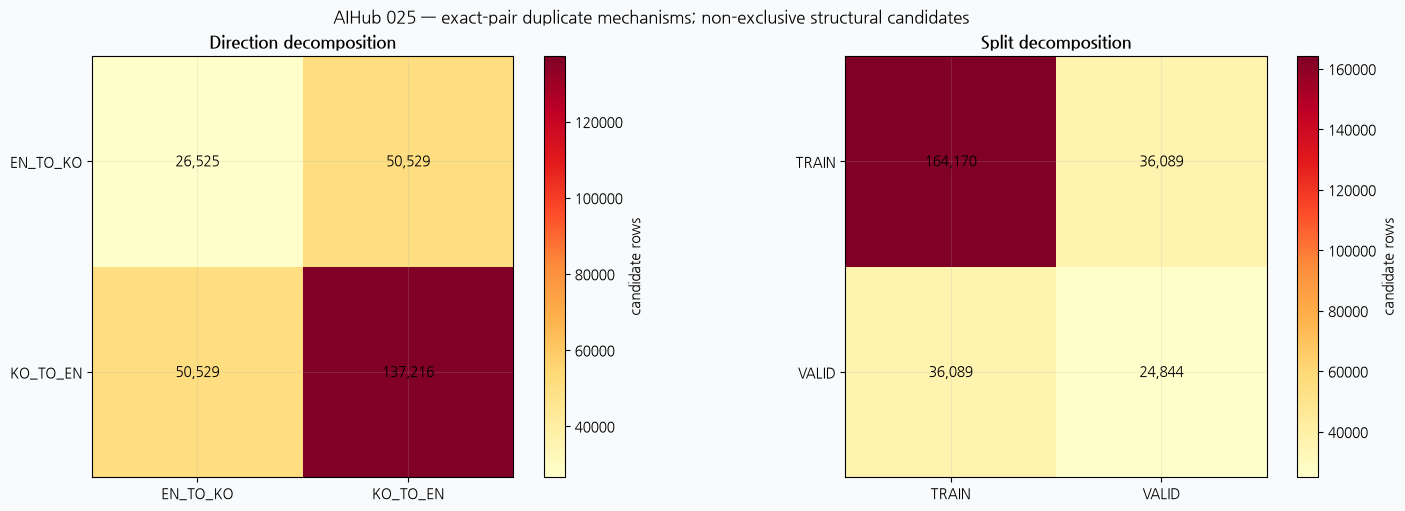

### direction_split_domain_full_population

,direction,split,raw_domain,record_count
1,EN_TO_KO,TRAIN,일상생활,449952
0,EN_TO_KO,TRAIN,해외고객과의채팅,270138
2,EN_TO_KO,TRAIN,해외영업,480217
6,EN_TO_KO,VALID,해외영업,150038
4,KO_TO_EN,TRAIN,일상생활,399904
5,KO_TO_EN,TRAIN,해외고객과의채팅,240094
3,KO_TO_EN,TRAIN,해외영업,560002
7,KO_TO_EN,VALID,일상생활,49901
9,KO_TO_EN,VALID,해외고객과의채팅,29989
8,KO_TO_EN,VALID,해외영업,70110


### direction_source_domain_full_population

,direction,raw_source,raw_domain,record_count
1,EN_TO_KO,크라우드 소싱,일상생활,449952
0,EN_TO_KO,크라우드 소싱,해외고객과의채팅,270138
2,EN_TO_KO,크라우드 소싱,해외영업,630255
4,KO_TO_EN,SBS,일상생활,449805
5,KO_TO_EN,크라우드소싱,해외고객과의채팅,270083
3,KO_TO_EN,크라우드소싱,해외영업,630112


### duplicate_mechanism_decomposition

...

,SBS_record_count,SBS_outside_KO_TO_EN_count,SBS_outside_daily_life_domain_count,observed_only_in_KO_TO_EN_and_daily_life
0,449805,0,0,True


### crowd_source_variant_observation

,direction,raw_source,raw_domain,record_count,classification
1,EN_TO_KO,크라우드 소싱,일상생활,449952,DISTINCT_RAW_CATEGORY_STRINGS / PROVENANCE_NOT...
0,EN_TO_KO,크라우드 소싱,해외고객과의채팅,270138,DISTINCT_RAW_CATEGORY_STRINGS / PROVENANCE_NOT...
2,EN_TO_KO,크라우드 소싱,해외영업,630255,DISTINCT_RAW_CATEGORY_STRINGS / PROVENANCE_NOT...
5,KO_TO_EN,크라우드소싱,해외고객과의채팅,270083,DISTINCT_RAW_CATEGORY_STRINGS / PROVENANCE_NOT...
3,KO_TO_EN,크라우드소싱,해외영업,630112,DISTINCT_RAW_CATEGORY_STRINGS / PROVENANCE_NOT...


### canonical_domain_mapping_preview

,raw_domain,proposed_canonical_domain,record_count
0,해외고객과의채팅,dialogue,540221
1,일상생활,general,899757
2,해외영업,other,1260367


In [4]:
targeted = targeted_025(Path(CONFIG['raw_root']), TARGET_OUTPUT_DIR, TARGET_FIGURE_DIR)
for name, frame in targeted.items():
    display(Markdown(f"### {name}"))
    display(frame)


## 5. Interpretation scaffold

관찰:

원인 후보:

제한: local raw aggregate이며 official identity/provenance를 확정하지 않는다.

결론: Research Director reconciliation 전에는 source rank, exclusion, Tier를 결정하지 않는다.

## 6. Export validation

In [5]:
required = profile_paths + figure_paths
for path in required:
    assert path.exists(), path
for frame_name in ["inventory", "record_counts", "schema", "length_summary", "noise", "categories", "duplicates"]:
    frame = result[frame_name]
    assert not {"ko", "en", "ko_preview", "en_preview", "원문", "번역문", "URL"}.intersection(frame.columns)
assert result["summary"]["raw_text_exported"] is False
assert result["summary"]["text_hash_exported"] is False
print("SANITIZED NOTEBOOK PASS")
print("raw text rows exported: 0")
print("text hashes exported: 0")


SANITIZED NOTEBOOK PASS
raw text rows exported: 0
text hashes exported: 0
